# Heart Disease Classification

## Objective:

Build a machine learning model that predicts whether a patient has a heart disease or not.




## Structure of the Notebook:

```

1. Business Problem
        ↓
2. BusinesValueve
        ↓
3. Dataset Understanding
        ↓
4. Feature Description
        ↓
5. Target Variable
        ↓
6. Exploratory Data Analysis (EDA)
        ↓
7. Data Preprocessing
      • Missing values
      • Duplicate values
      • Encoding categorical variables
      • Feature selection
        ↓
8. Train/Test Split
        ↓
9. Feature Scaling
        ↓
10. Model Building
      • Logistic Regression
        ↓
11. Prediction
      • Class probabilities
      • Predicted classes
        ↓
12. Model Evaluation
      • Accuracy
      • Precision
      • Recall
      • F1-score
      • ROC-AUC
      • Confusion Matrix
        ↓
13. Model Interpretation
      • Feature coefficients
      • Important predictors
      • Business interpretation
        ↓
14. Conclusion & Business Impact

# **1. Business Problem :**

- Hospitals and healthcare providers want to identify patients who are at high risk of heart disease as early as possible so they can recommend further diagnostic tests and treatment before the condition becomes severe.

- Currently, diagnosing heart disease often requires:

    - ECGs
    - Stress tests
    - Echocardiograms
    - Angiography
    - Cardiologist consultation

- These tests can be expensive, time-consuming, and may not be immediately available.

- A machine learning model can act as a clinical decision support tool by estimating a patient's likelihood of heart disease based on readily available clinical measurements.

# **2. Business Value:**

**1. Early Risk Detection:** The model can identify patients who are likely to have heart disease before symptoms become severe.

- Benefits:
    - Earlier treatment
    - Reduced complications
    - Better patient outcomes
 
**2. Assist Doctors (Not Replace Them):** Our model should not replace doctors. Instead, it helps doctors by acting as a decision support system.

- Example: Patient visits the hospital. Doctor feds below details to the model:
    - Age
    - Blood pressure
    - Cholesterol
    - Chest pain type
    - ECG result

- Model predicts: 92% chance of heart disease

- The doctor may decide to order additional tests immediately.

- Without the model, this patient might have been considered low priority.

**3. Hospital Resource Allocation:** Hospitals cannot perform expensive tests on every patient. 

- The model helps identify patients who should receive:

    - Angiography
    - Stress tests
    - Echocardiography

- This saves time, money, and hospital resources

----
## **3. Loading and understanding the Dataset**

In [10]:
import pandas as pd

df = pd.read_csv("C:\\Users\\hp\\Downloads\\heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### 3.1 Shape of the dataset:
----

In [12]:
print("1. Shape of dataset :", df.shape)

print("2. Columns are:" ,df.columns)


1. Shape of dataset : (920, 16)
2. Columns are: Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')



**Observations:**
- 920 observations (patients)
- 15 input features
- 1 target variable


The dataset contains 920 rows (patient records) and 16 columns. Each row represents one patient's clinical information. Out of the 16 columns, 15 are input features describing the patient's demographic and medical characteristics, while num is the target variable that indicates the presence or absence of heart disease.


### 3.2 Data Information:
---

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


**Observations :**

The dataset contains a mix of numerical and categorical features.

- There are 5 float-type columns, 3 integer-type columns, and 8 categorical (object) columns.
- Several features contain missing values, including trestbps, chol, fbs, thalch, exang, oldpeak, slope, ca, and thal.
- Among these, ca, thal, and slope have a significant number of missing values and will require careful preprocessing before building the machine learning model.

### 3.3 Summary Statistics(numerical columns)
----

In [18]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


**Observations:**

**1. Age:**  The average age of patients in this dataset is approximately 53 years. The youngest patient is 28 years old, while the oldest is 77 years old, indicating that the dataset mainly consists of middle-aged and older adults.

**2. Resting Blood Pressure (trestbps):**

    - Resting blood pressure measurements are available for 861 out of 920 patients.

    - The average resting blood pressure is approximately 132 mmHg, with values ranging from 0 to 200 mmHg.

    - A resting blood pressure value of 0 mmHg is not medically realistic and may represent missing or incorrectly recorded data, which should be           investigated during data preprocessing.

**3. Serum Cholesterol (chol):**

    - Cholesterol measurements are available for 890 patients.

    - The average cholesterol level is approximately 199 mg/dL, with values ranging from 0 to 603 mg/dL.

    - Similar to blood pressure, a cholesterol value of 0 mg/dL is not physiologically possible and may indicate missing or erroneous data.


**4. Maximum Heart Rate (thalch):**

    - Maximum heart rate was recorded for 865 patients.

    - The average maximum heart rate achieved is approximately 138 beats per minute, with values ranging from 60 to 202 bpm.


**5. ST Depression (oldpeak):**

    - The oldpeak feature is available for 858 patients.

    - The average value is approximately 0.88, with observations ranging from -2.6 to 6.2. Negative values and unusually high values should be  examined 
    -further during exploratory data analysis to determine whether they represent valid measurements or data quality issues.


**6. Number of Major Vessels (ca):**


    - The ca feature contains values for only 309 out of 920 patients, indicating that a large portion of this feature is missing.
      
    - Among the available observations, the average value is approximately 0.68, with values ranging from 0 to 3. Due to the high percentage of     missing data, this feature will require special attention during preprocessing.


### 3.4 Categorical Variables Summary
----

- The dataset contains several categorical variables including patient sex, chest pain type, ECG results, exercise-induced angina, ST slope, and thalassemia status.
   
- These variables will require encoding before they can be used by most machine learning algorithms.

***
## **4. Feature Description:**

	
	Column Descriptions:
	
	• id (Unique id for each patient)
	
	• age (Age of the patient in years)
	
	• origin (place of study)
	
	• sex (Male/Female)
	
	• cp chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
	
	• trestbps resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
	
	• chol (serum cholesterol in mg/dl)
	
	• fbs (if fasting blood sugar > 120 mg/dl)
	
	• restecg (resting electrocardiographic results) -- Values: [normal, stt abnormality, lv hypertrophy]
	
	• thalach: maximum heart rate achieved
	
	• exang: exercise-induced angina (True/ False)
	
	• oldpeak: ST depression induced by exercise relative to rest
	
	• slope: the slope of the peak exercise ST segment
	
	• ca: number of major vessels (0-3) colored by fluoroscopy
	
	• thal: [normal; fixed defect; reversible defect]
	
	• num: the predicted attribute
	


## **5. Target Variable(num):**


### 5.1 Understanding the classes:
----

In [25]:
df["num"].unique()

array([0, 2, 1, 3, 4], dtype=int64)

**Observations :**

- The target variable **num** has five classes.
- Classes range from 0 - 4

- As per documentation:
    - the target variable represents the diagnosis of heart disease.
    -  A value of 0 indicates that the patient does not have heart disease.
    -  Values 1 to 4 indicate the presence of heart disease, where higher values correspond to greater severity of the condition.n.

### 5.2 Distribution of the target (How many patients belong to each class?)
---

In [28]:
df["num"].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

**Observations**:
  
-  The dataset contains 411 patients without heart disease (num = 0) and 509 patients with heart disease (num = 1–4).
- Since the objective of this project is to predict whether a patient has heart disease or not, the target variable will later be converted into a binary target:
    - 0 → No Heart Disease
    - 1–4 → Heart Disease

### 5.3 Is the dataset balanced?
---

- This matters because an imbalanced dataset can make accuracy misleading.

- so we calculate percentages here to understand the balance more neatly.

In [31]:
df["num"].value_counts(normalize=True)*100

num
0    44.673913
1    28.804348
2    11.847826
3    11.630435
4     3.043478
Name: proportion, dtype: float64


**Observations :**

- *Approximately 45% of the patients do not have heart disease, while 55% have heart disease. The classes are reasonably balanced.*

### 5.4 Does the target match the business problem?
------

**NO.** 

- Business problem:  Predict whether a patient has heart disease or not
  
- The target in this dataset contains five classes but our business objective is to build a model that would predict just the presence of disease or not.
- objective here is binary classification, therefore, the target variable will be converted into two classes.

### 5.5. Deciding the modeling problem
-----

- Originally, the dataset represents a multiclass classification problem.

- For this project, it will be converted into a binary classification problem.



## **6. Exploratory Data Analysis (EDA)**

- EDA is the stage where we investigate our data a bit further.
- This stage is all about uncovering patterns as well as issues in the dataset.
- This stage is crucial because we will understand what needs preprocessing, whether the classes are balanced or not, and why?

  - Because our model is eventually going to learn from this very dataset.
  - So, we must give it correct, unbiased data so that it can generalize better.


#### For this dataset this is the story we are supposed to take into account:

> *We have 920 patient records. We want to build a model that predicts whether a patient has heart disease. Before building the model, we need to understand the patients, the disease patterns, and any problems hidden in the data.*


### 6.1 What are we exactly trying to predict?
---
- The goal of this model is to predict whether a patient has heart disease or not.

- However, our dataset is a multiclass classification dataset. 
- Since our business objective is binary classification, we'll create a column **business target** that would contain binary classification,
 - 0 → No disease    - 
1 → Diseas

- We'll not drop our original target column yete
  

In [37]:
#Look at every patient's num value. If it is 0, label them as no disease. Otherwise, label them as disease.

df["Heart Disease"] = df["num"].apply(lambda x : 0 if x == 0 else 1)

In [38]:
# verify

df[[ "num", "Heart Disease"]].head()

,num,Heart Disease
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


### 6.2 How many patients belong to each group?
---

- We will visualize using **Count plot** ( plot the graph for the target variable ).
- A count plot answers how many observations exist in each category?
- Because the target is categorical:

   - No disease
   - Disease

- We don't care about averages here. We care about counts, that's why we chose this plot

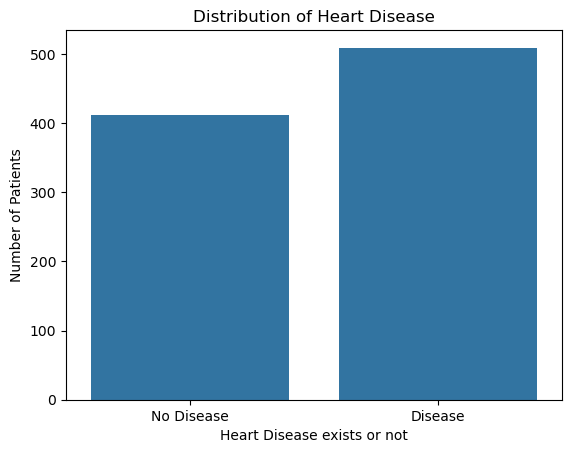

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x = "Heart Disease", data = df) # x = heart disease on x axis
                                              # This tells seaborn to use the dataframe called df.   

# Adding labels

plt.title("Distribution of Heart Disease")

plt.xlabel("Heart Disease exists or not")

plt.ylabel("Number of Patients")

#plt.legend(title='Heart Disease')

plt.xticks([0,1],  ["No Disease", "Disease"]) # By default Python shows: 0 and 1
                                                # But a doctor does not think: "patient belongs to class 1"
                                                # They think:"Patient has a disease"
                                                # So we replace: 0 → No Disease and 1 → Disease

plt.show()


### 6.3 Heart disease distribution by sex
----

- When building a model, it’s easy to treat features as just numbers. But to build a model that actually works in a hospital, we need to ask: "Does the data match real-world medical reality?"

- In cardiovascular medicine, men and women present with heart disease differently due to hormonal differences, arterial structure, and average age of onset.
- So, if our dataset has a massive demographic imbalance (e.g., 80% men and 20% women), our future model might learn patterns that work great for male patients, but perform poorly on female patients. We need to catch this now so we aren't surprised during evaluation

- By plotting sex vs. Heart Disease, we are answering two critical questions:

  - The Medical Question: Is sex a strong predictor in our dataset?

  - The Fairness/Data Question: Do we have enough data for both male and female patients to make reliable predictions for both?

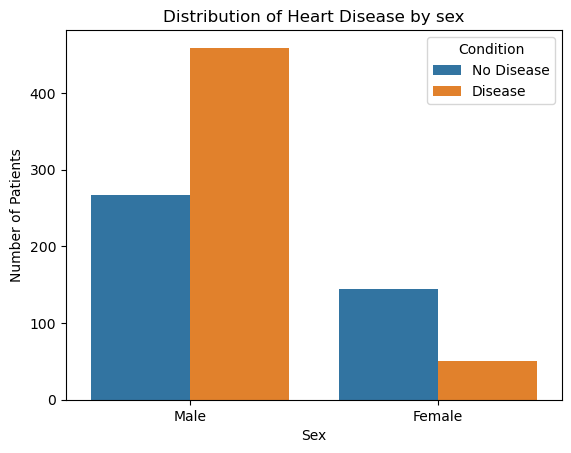

In [81]:
sns.countplot(x = "sex" ,hue="Heart Disease", data =df)

plt.title("Distribution of Heart Disease by sex")

plt.xlabel("Sex")

plt.ylabel("Number of Patients")

plt.legend(title='Condition', labels=['No Disease', 'Disease'])


plt.show()



In [43]:
# 2. Calculating exact percentage within each group
pd.crosstab(df['sex'], df['Heart Disease'], normalize='index') * 100

Heart Disease,0,1
sex,,
Female,74.226804,25.773196
Male,36.776860,63.223140


### 6.4 Heart disease distribution by age
----
- Age can also serve as a crucial metric that can potentially describe how age impacts heart disease.
- Since age is a continuous feature we will use plots such as box plot.

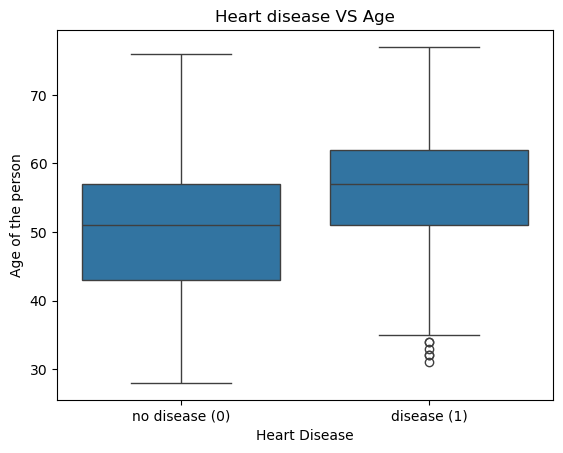

In [120]:
sns.boxplot(x = "Heart Disease" , y = "age" , data = df)

plt.title("Heart disease VS Age")

plt.xlabel("Heart Disease")

plt.ylabel("Age of the person")

plt.xticks([0 , 1] , ["no disease (0)" , "disease (1)"])

plt.show()

### 6.4 Feature Relationships & Correlation Analysis
----

#### Objective:

To compute the pairwise correlation between all numerical features and our target variable (Heart Disease), identifying which clinical metrics carry the strongest positive or negative predictive signals.

#### Correlation Matrix vs. Heatmap
---

#### 1. What is the difference?

- Correlation Matrix (df.corr()): The raw mathematical calculation. It computes the Pearson correlation coefficient (between $-1.0$ and $+1.0$) for every numerical pair and outputs a plain table of numbers.
  
- Heatmap (sns.heatmap()): The visual representation. It takes that raw matrix of numbers and paints colors on top of it so your brain can spot patterns instantly.
  
 $$\text{Correlation Matrix (Raw Numbers)} + \text{Seaborn (Color Scale)} = \text{Correlation Heatmap}$$

 ```

```

#### 2. Why do we combine them in code?

- A heatmap cannot draw itself; it requires data.

- corr_matrix = df.corr() creates the table of numbers.
  
- sns.heatmap(corr_matrix) takes that table and turns positive numbers Red, negative numbers Blue, and weak relationships Neutral.

  ```
  ```

#### 3. How to read the values relative to Heart Disease?

- +1.0 (Bright Red): Strong positive relationship (as feature goes UP, Heart Disease risk goes UP).
  
- -1.0 (Deep Blue): Strong negative relationship (as feature goes UP, Heart Disease risk goes DOWN).
  
-  0.0 (Neutral/Light): No linear relationship (feature gives little to no predictive signal on its own).
  

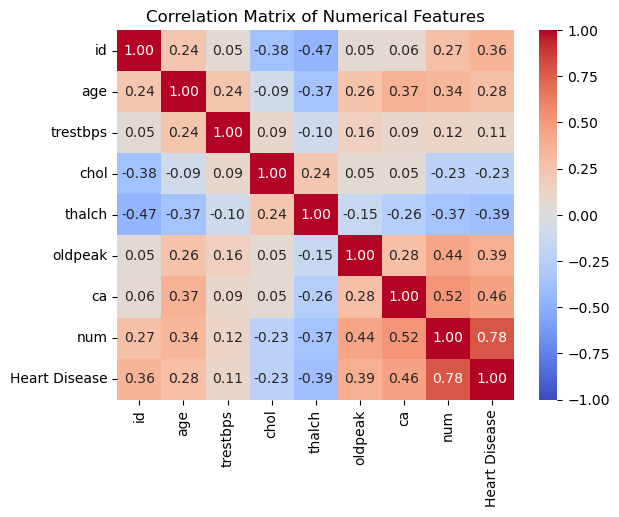

In [192]:
import numpy as np

# Select only numerical columns for correlation calculation
numeric_cols = df.select_dtypes(include=[np.number]).columns


# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

t
Parameters

| Parameter | Purpose | What it Controls |
| :--- | :--- | :--- |
| **`corr_matrix`** | **Data Input** | The grid of numerical values produced by `df.corr()`. Seaborn uses this to lay out the rows and columns. |
| **`annot=True`** | **Text Annotation** | Setting this to `True` prints the exact numeric correlation value inside each square cell. |
| **`fmt=".2f"`** | **Number Formatting** | Rounds the printed numbers to **2 decimal places** (e.g., `0.42` instead of `0.421839`). Keeps the plot clean and readable. |
| **`cmap='coolwarm'`** | **Color Palette** | Sets the color scheme. Warm colors (**Red**) represent positive correlations; cool colors (**Blue**) represent negative correlations. |
| **`vmin=-1` / `vmax=1`** | **Color Scale Boundaries** | Locks the floor and ceiling of the color scale strictly from **$-1.
```
```0$ to $+1.0$**. |

> **💡 Why set `vmin=
-1` and `vmax=1`?**
> Locking the scale ensures **true scale honesty**. Bright red *always* means $+1.0$ and deep blue *always* means $-1.0$, preventing Seaborn from auto-scaling based only on the dataset's relative highs and lows.

#### Observations from above matrix:
*****
**1. Target Relationships (Heart Disease)**:

- **num (+0.78):** Shows a near-perfect relationship with heart disease because in our original dataset num is the target variable.
  
- **ca (+0.46):** Number of Major Vessels (0-3) Colored by Fluoroscopy.
  
  - **What it means in normal English:** Doctors inject a special dye into the blood and take an X-ray movie (fluoroscopy) to see the heart's main    highways. If a highway is open, blood flows right through. If it is clogged, the dye stops.
  
  - **The simple takeaway:** A score of $0$ means clear, open pipes. A score of $3$ means 3 main pipes are clogged with plaque. More clogged pipes = higher heart disease risk.
  - **In our dataset, ca has a near-perfect correlation with heart disease.** So, when more heart pipes are blocked, the chances of having heart disease are higher.
  ```
  ```    
- **oldpeak (+0.39):** ST Depression Induced by Exercise Relative to Rest.
  
  - **What it means in normal English:** When you are running on a treadmill during a stress test, your heart works hard and demands tons of oxygen. An ECG machine draws lines tracking your heart rate. One specific segment of that wave line is called the "ST segment.
    
  - **The simple takeaway:** If that line drops or sags down (oldpeak) while you exercise, it means your heart muscle is literally suffocating and crying out for oxygen because blocked arteries aren't letting enough blood through. A bigger drop = more severe oxygen starvation.
  - In our dataset, oldpeak shows a positive correlation with heart disease. That means more the drop in the ST segment, more is the chance of having heart disease.
    
  -  **Why oldpeak is a Positive Correlation (+0.39):** `oldpeak` measures the *amount* of ST-depression in millimeters (e.g., $0.0\text{ mm}$, $1.5\text{ mm}$, $3.8\text{ mm}$). Even though the ECG line physically sags downward, a **larger drop measurement** represents greater heart distress—meaning as the `oldpeak` number goes UP, heart disease risk also goes UP.
    ```
    ```
    
- **thalch (-0.39):** Maximum Heart Rate Achieved.
  
  - **What it means in normal English:** How fast your heart can physically beat when you are pushing yourself to the limit on a treadmill.
    
  - **The simple takeaway:** A healthy, strong heart can safely rev up its engine like a sports car (e.g., hitting $160$–$180$ beats per minute). A weak or disease-damaged heart gives out, gets painful, or tires early (e.g., capping out at $110$ beats per minute). Higher max speed = healthier heart.
  - **thalch has a negative correlation with heart disease**, meaning more the heart rate during intense activity lesser the chances of having heart disease.
    ```
    ```
- **age ($+0.28$) & id ($+0.36$):** Moderate positive correlations. Age naturally increases risk, but id is just an arbitrary row index that carries no real clinical value.
  ```
  ```
- **chol ($-0.23$) & trestbps ($+0.11$):** Relatively weak correlations. While cholesterol and blood pressure are long-term risk factors, immediate stress-test indicators (oldpeak, thalch) are much stronger real-time signals.

-----Pausing it here for a bit-----